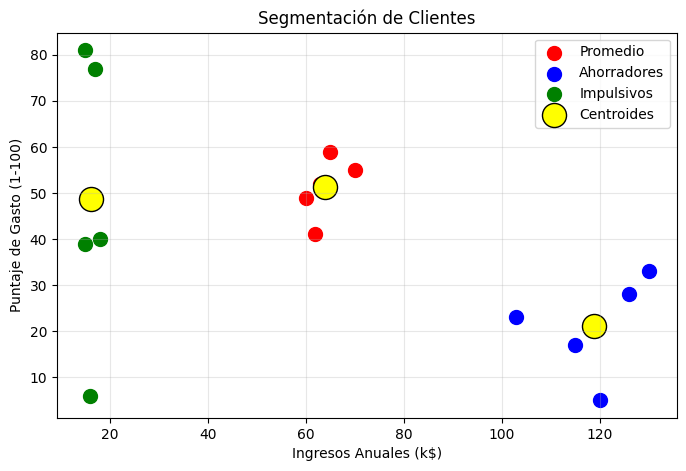

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Datos sintéticos: [Ingreso_k$, Gasto_0-100]
data = np.array([[15, 39], [15, 81], [16, 6], [17, 77], [18, 40],
                     [60, 49], [62, 41], [63, 52], [65, 59], [70, 55],
                     [126, 28], [130, 33], [103, 23], [115, 17], [120, 5]])

def segmentacion_compras():
    """
    Simula la segmentacion de clientes basada en Ingresos y Gasto.
    """
    # Datos sintéticos: [Ingreso_k$, Gasto_0-100]
    data = np.array([[15, 39], [15, 81], [16, 6], [17, 77], [18, 40],
                     [60, 49], [62, 41], [63, 52], [65, 59], [70, 55],
                     [126, 28], [130, 33], [103, 23], [115, 17], [120, 5]])

    # Aplicar K-Means con K=3
    '''
    init='k-means++':  Esto especifica el método para inicializar los centroides. 'k-means++' es una forma inteligente de elegir centros de clúster iniciales que tienden a acelerar la convergencia.
    n_init=10:  Esto significa que el algoritmo se ejecutará 10 veces con diferentes semillas de centroide, y el resultado final será la mejor salida de estas 10 ejecuciones consecutivas en términos de inercia (suma de las distancias cuadradas de las muestras a su centro de clúster más cercano).
    '''
    kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
    y_predict = kmeans.fit_predict(data)

    # Visualización
    plt.figure(figsize=(8, 5))
    colors = ['red', 'blue', 'green']
    labels = ['Promedio', 'Ahorradores', 'Impulsivos']

    # s=100 specifies the size of the markers (points) in the scatter plot.
    for i in range(3):
        plt.scatter(data[y_predict == i, 0], data[y_predict == i, 1],
                    s=100, c=colors[i], label=labels[i])

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                s=300, c='yellow', label='Centroides', edgecolors='black')
    plt.title('Segmentación de Clientes')
    plt.xlabel('Ingresos Anuales (k$)')
    plt.ylabel('Puntaje de Gasto (1-100)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return data

data = segmentacion_compras()

**Metodo del Codo**

El método Elbow es una heurística que se utiliza para determinar el número óptimo de grupos a utilizar en un algoritmo de agrupamiento de K-medias. El método implica trazar la variación explicada en función del número de conglomerados y seleccionar el codo de la curva como el número de conglomerados a utilizar. La variación explicada se define como la suma de distancias al cuadrado entre los puntos de datos y los centros de sus grupos asignados, también conocida como suma de cuadrados dentro del grupo (WCSS).

La intuición detrás del método Elbow es que a medida que aumenta el número de grupos, el WCSS generalmente disminuirá porque cada punto de datos estará más cerca de su centro de grupo asignado. Sin embargo, más allá de cierto punto, la ganancia marginal en la reducción de WCSS comenzará a disminuir, lo que resultará en un aplanamiento de la curva. Este punto de aplanamiento se conoce como "codo" y representa la cantidad óptima de grupos a usar.

In [8]:
# Visualizacion
import plotly.express as px
import plotly.graph_objs as go
import matplotlib.pyplot as plt

# crear una lista para almacenar la suma de distancias al cuadrado para cada k
ssd = []

# Entrena KMeans con diferentes valores de k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    #La inercia o intertia, en el contexto del K-Means, es la suma de todas las distancias de las observaciones de un clúster a su centroide.
    ssd.append(kmeans.inertia_)

# crear un dataframe con los valores k y el ssd correspondiente
df = pd.DataFrame({'k': range(1, 11), 'ssd': ssd})

# crear el diagrama de líneas usando Plotly Express
fig = px.line(df, x='k', y='ssd', title='Método del codo') #Elbow Method
fig.update_traces(mode='markers+lines', marker=dict(size=8))
fig.show()

**K Optimo**, obtenido del Metodo del Codo   

tasa de disminución de la suma de las distancias al cuadrado (SSD) es más significativa.

In [11]:
import numpy as np

# Calculate the differences in ssd (first derivative)
differences = np.diff(ssd)

# Calculate the differences of the differences (second derivative)
differences_of_differences = np.diff(differences)

# The elbow point is typically where the second derivative is most negative (largest drop)
# We look for the index where this change is most significant
# Adding 1 to the index because k starts from 1, and diff reduces array size by 1
elbow_k_index = np.argmin(differences_of_differences) + 1

# The optimal k is this index plus 1 (since k starts from 1 and array indexing is 0-based)
optimal_k = elbow_k_index + 1

print(f"El valor óptimo de K (método del codo) es: {optimal_k}")

El valor óptimo de K (método del codo) es: 6


**Indice de la Silueta**

In [14]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score

# crear una lista para almacenar las puntuaciones de silueta para cada k
silhouette_scores = []

# Entrena KMeans con diferentes valores de k
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(data)
    silhouette_avg = silhouette_score(data, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

# encuentra la k con la puntuación de silueta más alta
best_k = np.argmax(silhouette_scores) + 2

# visualizar las puntuaciones de silueta vs k
fig = px.line(x=range(2, 11), y=silhouette_scores, title='Metodo de la Silueta')
fig.update_layout(xaxis_title='Number of Clusters (k)', yaxis_title='Silhouette Score')
fig.add_vline(x=best_k, line_dash='dash', line_color='red', annotation_text=f'Best k: {best_k}')
fig.show()

Con base en todas las puntuaciones obtenidas, podemos decir que "5" es el mejor valor para K (número de conglomerados).

In [21]:
# KMeans Clustering
kmeans = KMeans(n_clusters=5, random_state=42)

# Ajustar el modelo KMeans en train_ds
y_predict = kmeans.fit_predict(data)

# Obtener etiquetas de conglomerados y centroides
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

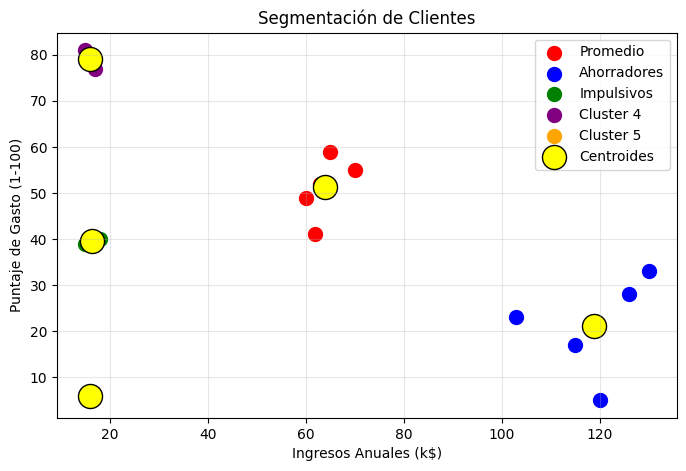

In [29]:
# Visualización
plt.figure(figsize=(8, 5))

# Define colors for up to 5 clusters
all_colors = ['red', 'blue', 'green', 'purple', 'orange']
# Define labels for up to 5 clusters
all_labels = ['Promedio', 'Ahorradores', 'Impulsivos', 'Cluster 4', 'Cluster 5']

# s=100 specifies the size of the markers (points) in the scatter plot.
for i in range(kmeans.n_clusters): # Iterate up to the actual number of clusters (which is 5)
  plt.scatter(data[y_predict == i, 0], data[y_predict == i, 1],
              s=100, c=all_colors[i], label=all_labels[i])

# Plot centroids once after all data points
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroides', edgecolors='black')

plt.title('Segmentación de Clientes')
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntaje de Gasto (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()